<a href="https://colab.research.google.com/github/shachi-i/Celestial-Intelligence/blob/main/Celestial_Intelligence_pulsar_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df = pd.read_csv("HTRU_2.csv")

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   140.5625      17897 non-null  float64
 1   55.68378214   17897 non-null  float64
 2   -0.234571412  17897 non-null  float64
 3   -0.699648398  17897 non-null  float64
 4   3.199832776   17897 non-null  float64
 5   19.11042633   17897 non-null  float64
 6   7.975531794   17897 non-null  float64
 7   74.24222492   17897 non-null  float64
 8   0             17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB
None


In [5]:
print(df.describe())

           140.5625   55.68378214  -0.234571412  -0.699648398   3.199832776  \
count  17897.000000  17897.000000  17897.000000  17897.000000  17897.000000   
mean     111.078321     46.549021      0.477897      1.770417     12.614926   
std       25.652705      6.843040      1.064056      6.168058     29.473637   
min        5.812500     24.772042     -1.876011     -1.791886      0.213211   
25%      100.929688     42.375426      0.027108     -0.188528      1.923077   
50%      115.078125     46.946435      0.223241      0.198736      2.801839   
75%      127.085938     51.022887      0.473349      0.928206      5.464883   
max      192.617188     98.778911      8.069522     68.101622    223.392141   

        19.11042633   7.975531794   74.24222492            0  
count  17897.000000  17897.000000  17897.000000  17897.00000  
mean      26.326918      8.303574    104.859419      0.09158  
std       19.471042      4.506217    106.517270      0.28844  
min        7.370432     -3.139270   

In [6]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 140.5625        0
55.68378214     0
-0.234571412    0
-0.699648398    0
3.199832776     0
19.11042633     0
7.975531794     0
74.24222492     0
0               0
dtype: int64


In [7]:
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [8]:

columns = [
    "Mean_IP", "Std_IP", "ExcessKurt_IP", "Skewness_IP",
    "Mean_DM", "Std_DM", "ExcessKurt_DM", "Skewness_DM",
    "Label"
]
df = pd.read_csv("HTRU_2.csv", header=None, names=columns)
print("Missing values:\n", df.isnull().sum())
df.head()

Missing values:
 Mean_IP          0
Std_IP           0
ExcessKurt_IP    0
Skewness_IP      0
Mean_DM          0
Std_DM           0
ExcessKurt_DM    0
Skewness_DM      0
Label            0
dtype: int64


,Mean_IP,Std_IP,ExcessKurt_IP,Skewness_IP,Mean_DM,Std_DM,ExcessKurt_DM,Skewness_DM,Label
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


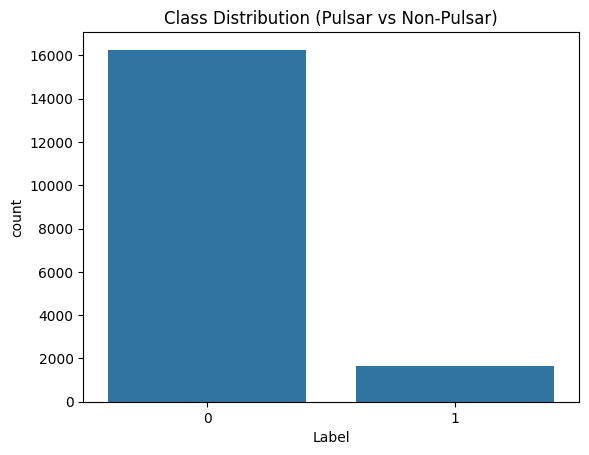

,count
Label,
0,16259
1,1639


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(x=df["Label"])
plt.title("Class Distribution (Pulsar vs Non-Pulsar)")
plt.show()


df["Label"].value_counts()


Since the dataset is highly imbalaced, it might lead to a bias. So we

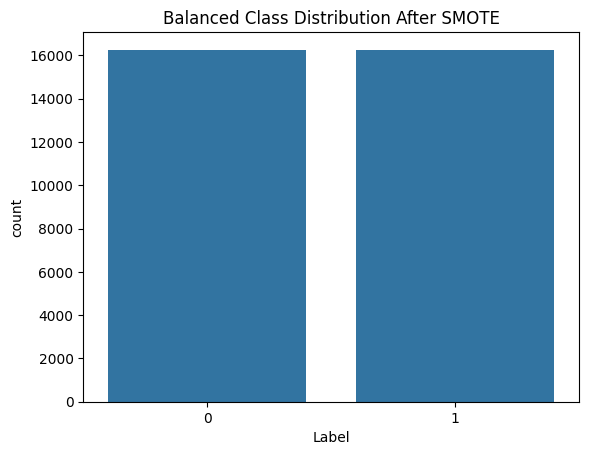

,count
Label,
0,16259
1,16259


In [10]:
from imblearn.over_sampling import SMOTE

# Separate features and labels
X = df.drop(columns=["Label"])
y = df["Label"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert back to DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled["Label"] = y_resampled

# Verify new class distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_resampled["Label"])
plt.title("Balanced Class Distribution After SMOTE")
plt.show()

# Print exact counts
df_resampled["Label"].value_counts()


Fourier Transform Features (Frequency Analysis)

In [11]:
import numpy as np


df["FFT_Mean_IP"] = np.abs(np.fft.fft(df["Mean_IP"]))
df["FFT_Mean_DM"] = np.abs(np.fft.fft(df["Mean_DM"]))


df["FFT_Max_IP"] = df["FFT_Mean_IP"].apply(lambda x: np.max(x))
df["FFT_Max_DM"] = df["FFT_Mean_DM"].apply(lambda x: np.max(x))

df["FFT_Mean_IP"] = df["FFT_Mean_IP"].apply(lambda x: np.mean(x))
df["FFT_Mean_DM"] = df["FFT_Mean_DM"].apply(lambda x: np.mean(x))


df.drop(columns=["FFT_Mean_IP", "FFT_Mean_DM"], inplace=True)

df.head()


,Mean_IP,Std_IP,ExcessKurt_IP,Skewness_IP,Mean_DM,Std_DM,ExcessKurt_DM,Skewness_DM,Label,FFT_Max_IP,FFT_Max_DM
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,1.988109e+06,225772.525084
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,3.464480e+04,39065.232028
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,2.249421e+04,13990.414891
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,1.208588e+04,10787.884146
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,9.141645e+03,11215.347092


Wavelet Transform Features (Time-Frequency Analysis)

In [12]:
!pip install PyWavelets
import pywt
import numpy as np

def extract_wavelet_features(signal):
    # Convert the signal to a numpy array to ensure it has dimensions
    signal = np.array(signal)

    # If signal has more than one element, apply wavedec
    if signal.size > 1:
        coeffs = pywt.wavedec(signal, 'db4', level=3)  # Decomposing using Daubechies wavelet
        cA3, cD3, cD2, cD1 = coeffs  # Approximate and Detail Coefficients
        return np.mean(cA3), np.std(cD1), np.max(cD2)
    # If signal has only one element, return NaN for wavelet features
    else:
        return np.nan, np.nan, np.nan

# Apply wavelet transform on key signal features
df["Wavelet_Mean_IP"], df["Wavelet_Std_IP"], df["Wavelet_Max_IP"] = zip(*df["Mean_IP"].apply(extract_wavelet_features))
df["Wavelet_Mean_DM"], df["Wavelet_Std_DM"], df["Wavelet_Max_DM"] = zip(*df["Mean_DM"].apply(extract_wavelet_features))

df.head()

,Mean_IP,Std_IP,ExcessKurt_IP,Skewness_IP,Mean_DM,Std_DM,ExcessKurt_DM,Skewness_DM,Label,FFT_Max_IP,FFT_Max_DM,Wavelet_Mean_IP,Wavelet_Std_IP,Wavelet_Max_IP,Wavelet_Mean_DM,Wavelet_Std_DM,Wavelet_Max_DM
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,1.988109e+06,225772.525084,NaN,NaN,NaN,NaN,NaN,NaN
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,3.464480e+04,39065.232028,NaN,NaN,NaN,NaN,NaN,NaN
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,2.249421e+04,13990.414891,NaN,NaN,NaN,NaN,NaN,NaN
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,1.208588e+04,10787.884146,NaN,NaN,NaN,NaN,NaN,NaN
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,9.141645e+03,11215.347092,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df["DM_Approx"] = df["Mean_DM"] / (df["Std_DM"] + 1e-5)  # Adding small value to avoid division by zero
df.head()


,Mean_IP,Std_IP,ExcessKurt_IP,Skewness_IP,Mean_DM,Std_DM,ExcessKurt_DM,Skewness_DM,Label,FFT_Max_IP,FFT_Max_DM,Wavelet_Mean_IP,Wavelet_Std_IP,Wavelet_Max_IP,Wavelet_Mean_DM,Wavelet_Std_DM,Wavelet_Max_DM,DM_Approx
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,1.988109e+06,225772.525084,NaN,NaN,NaN,NaN,NaN,NaN,0.167439
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,3.464480e+04,39065.232028,NaN,NaN,NaN,NaN,NaN,NaN,0.112869
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,2.249421e+04,13990.414891,NaN,NaN,NaN,NaN,NaN,NaN,0.143540
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,1.208588e+04,10787.884146,NaN,NaN,NaN,NaN,NaN,NaN,0.173812
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,9.141645e+03,11215.347092,NaN,NaN,NaN,NaN,NaN,NaN,0.102795


In [14]:
print(df.columns)


Index(['Mean_IP', 'Std_IP', 'ExcessKurt_IP', 'Skewness_IP', 'Mean_DM',
       'Std_DM', 'ExcessKurt_DM', 'Skewness_DM', 'Label', 'FFT_Max_IP',
       'FFT_Max_DM', 'Wavelet_Mean_IP', 'Wavelet_Std_IP', 'Wavelet_Max_IP',
       'Wavelet_Mean_DM', 'Wavelet_Std_DM', 'Wavelet_Max_DM', 'DM_Approx'],
      dtype='object')


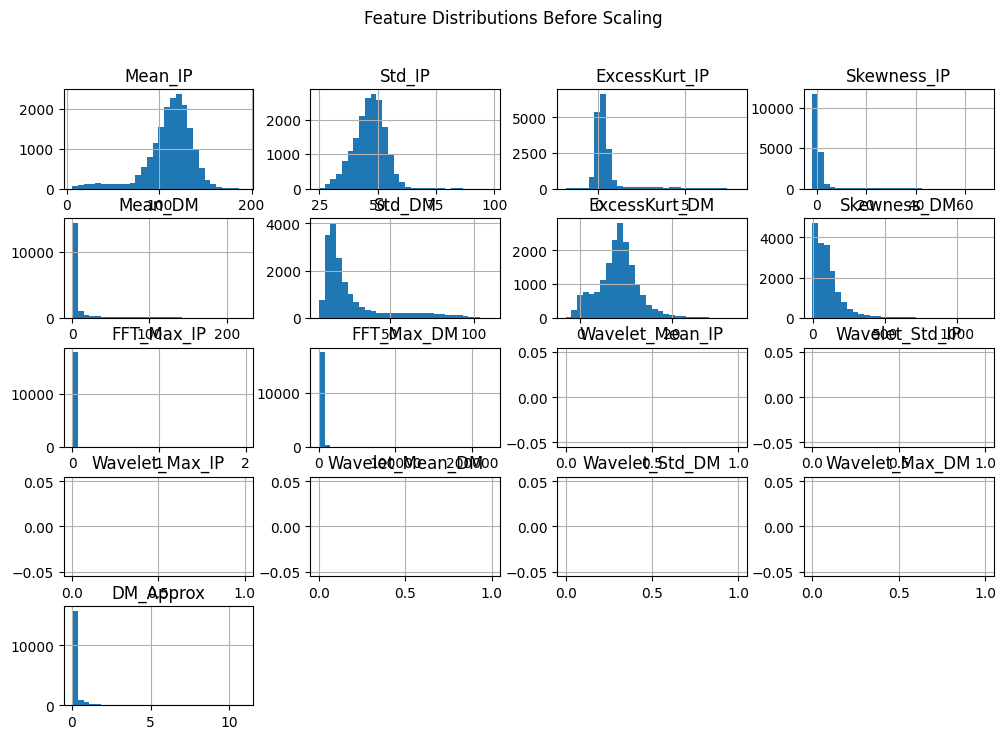

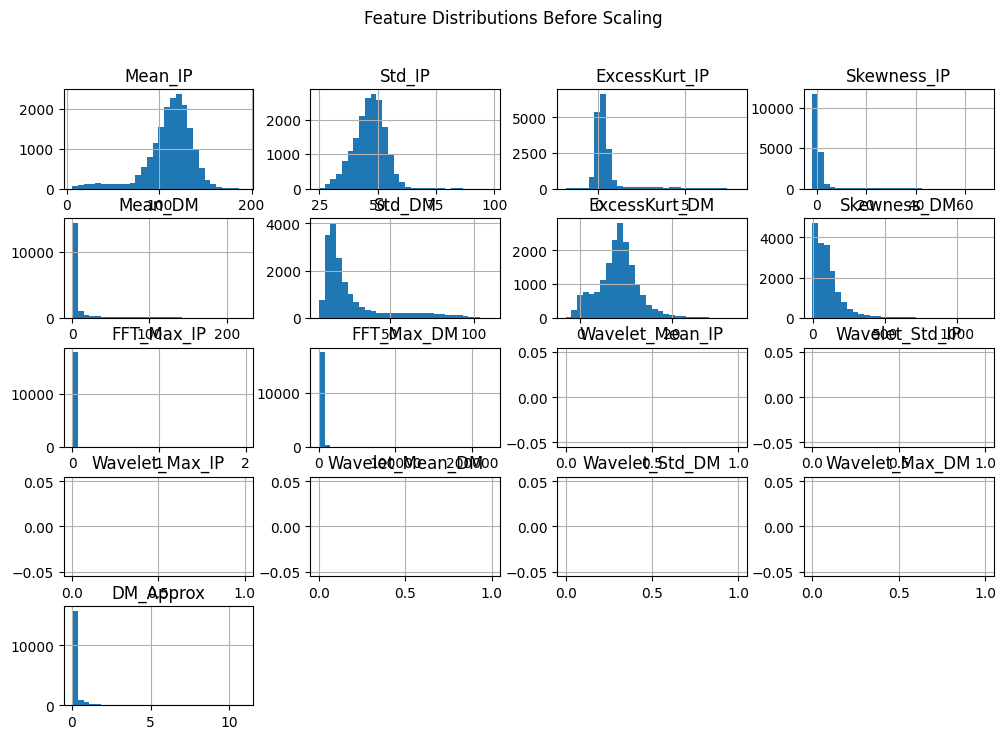

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Load your dataset
df = df.drop(columns=["Label"])  # Drop label for scaling

# Visualizing distributions before scaling
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Feature Distributions Before Scaling")
plt.show()
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Load your dataset
#df = df.drop(columns=["Label"])  # Drop label for scaling

# Visualizing distributions before scaling
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Feature Distributions Before Scaling")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/tmp/ipython-input-1627347925.py:23: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scaled_df.hist(ax=axes[i], bins=30)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(nu

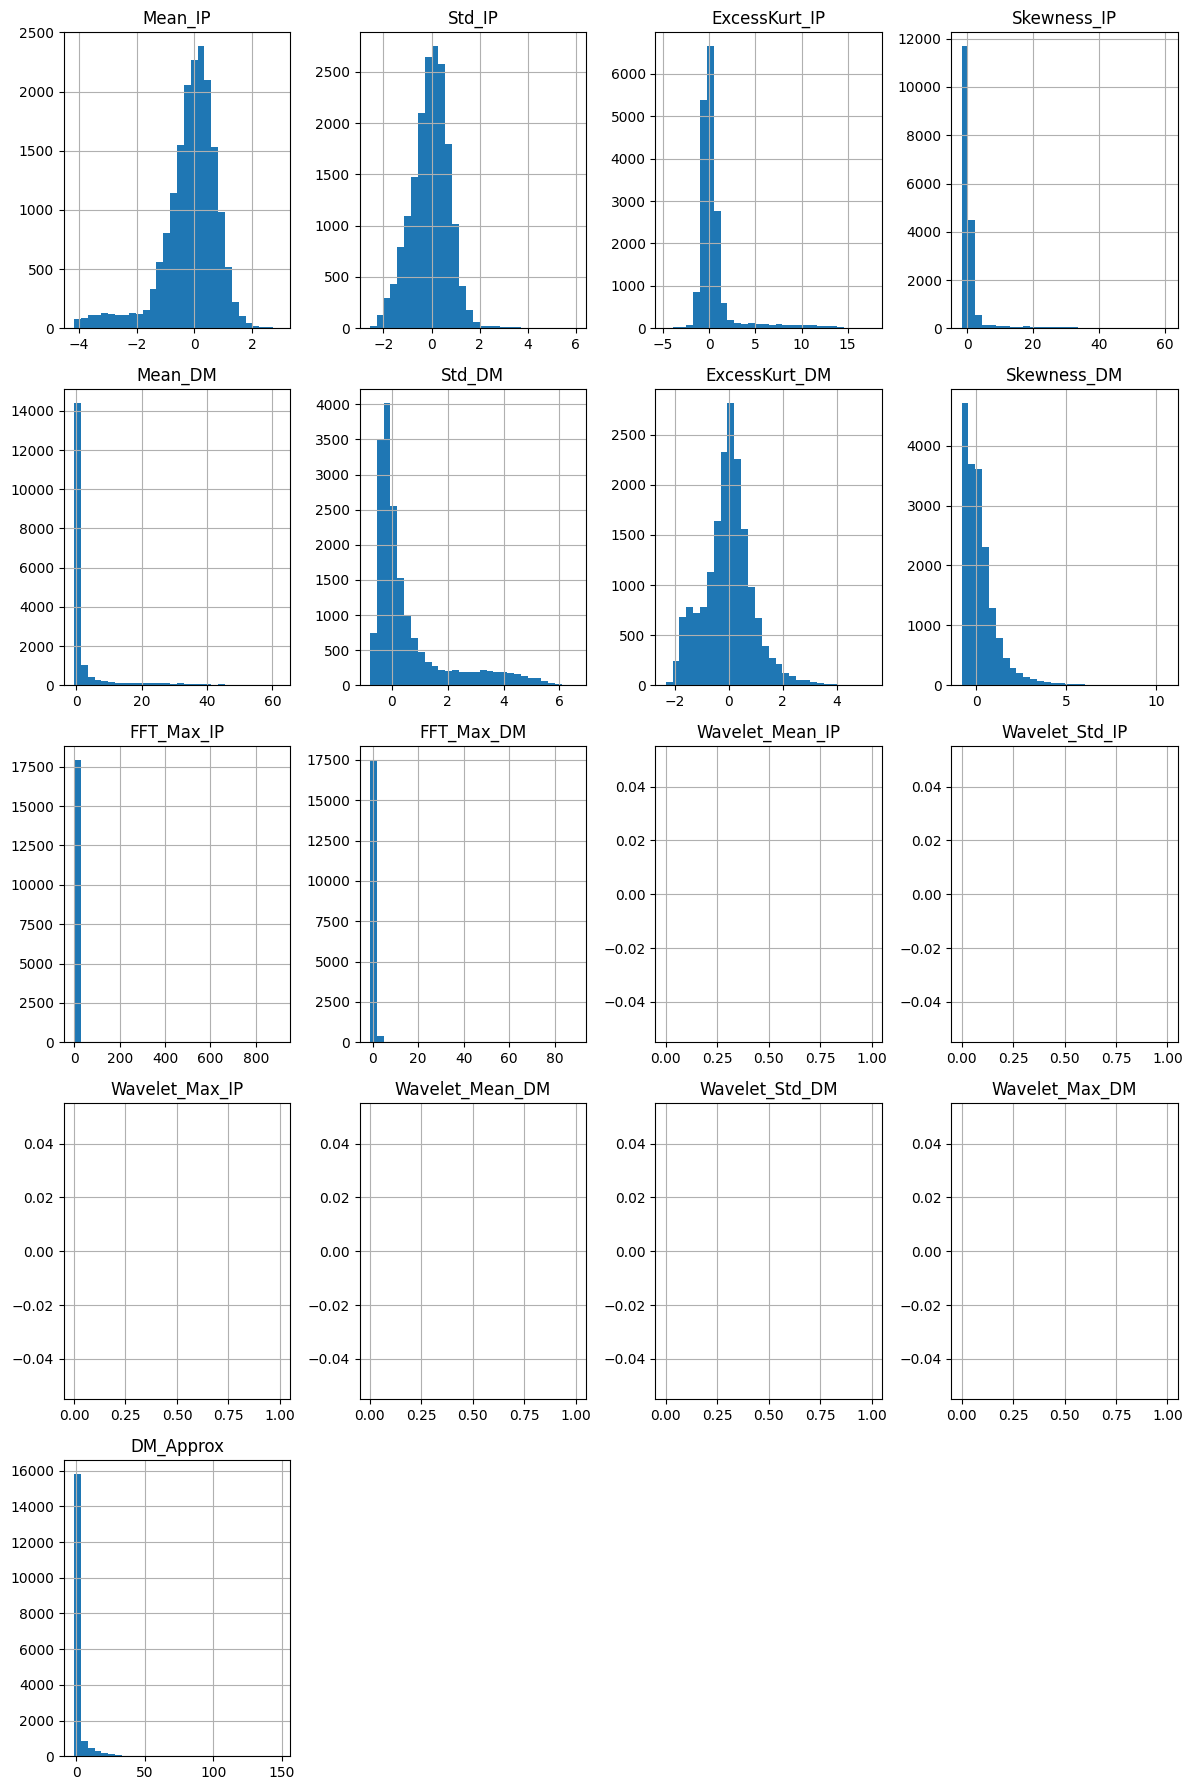

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


df_features = df


scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))

for i, (scaler_name, scaler) in enumerate(scalers.items()):
    scaled_data = scaler.fit_transform(df_features)  # Scale the data
    scaled_df = pd.DataFrame(scaled_data, columns=df_features.columns)


    scaled_df.hist(ax=axes[i], bins=30)
    axes[i].set_title(f"Feature Distributions After {scaler_name}", fontsize=14)

plt.tight_layout()
plt.show()


In [17]:
from sklearn.model_selection import train_test_split


original_df = pd.read_csv("HTRU_2.csv", header=None, names=columns)
y = original_df['Label']
X = scaled_df


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestClassifier


model_rfs = RandomForestClassifier(n_estimators=100, random_state=42)


model_rfs.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [31]:
from sklearn.metrics import accuracy_score, classification_report


y_pred_rfs = model_rfs.predict(X_test)


accuracy_rfs = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


print(classification_report(y_test, y_pred))


Model Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3259
           1       0.00      0.00      0.00       321

    accuracy                           0.91      3580
   macro avg       0.46      0.50      0.48      3580
weighted avg       0.83      0.91      0.87      3580



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
!pip install xgboost


In [21]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


In [22]:

y = original_df['Label']
X = scaled_df


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)


xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:59:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [32]:

y_pred_xgb = xgb_model.predict(X_test)


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {accuracy:.2f}")


print(classification_report(y_test, y_pred_xgb))


XGBoost Model Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3259
           1       0.92      0.85      0.89       321

    accuracy                           0.98      3580
   macro avg       0.95      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [33]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense


X_train_seq = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_seq = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_seq, y_train, epochs=20, batch_size=32, validation_data=(X_test_seq, y_test))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


448/448 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9028 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 2/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9094 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 3/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9089 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 4/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9083 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 5/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9084 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 6/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9109 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 7/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9117 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 8/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9064 - loss: nan - val_accuracy: 0.9103 - val_loss: nan
Epoch 9/20
448/448 ━

In [46]:
np.isnan(lstm_proba).sum()


np.int64(3580)

In [34]:

y_pred_lstm = (model_lstm.predict(X_test_seq) > 0.5).astype("int32")


from sklearn.metrics import accuracy_score, classification_report
print(f"LSTM Model Accuracy: {accuracy_score(y_test, y_pred_lstm):.2f}")
print(classification_report(y_test, y_pred_lstm))


112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
LSTM Model Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3259
           1       0.00      0.00      0.00       321

    accuracy                           0.91      3580
   macro avg       0.46      0.50      0.48      3580
weighted avg       0.83      0.91      0.87      3580



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


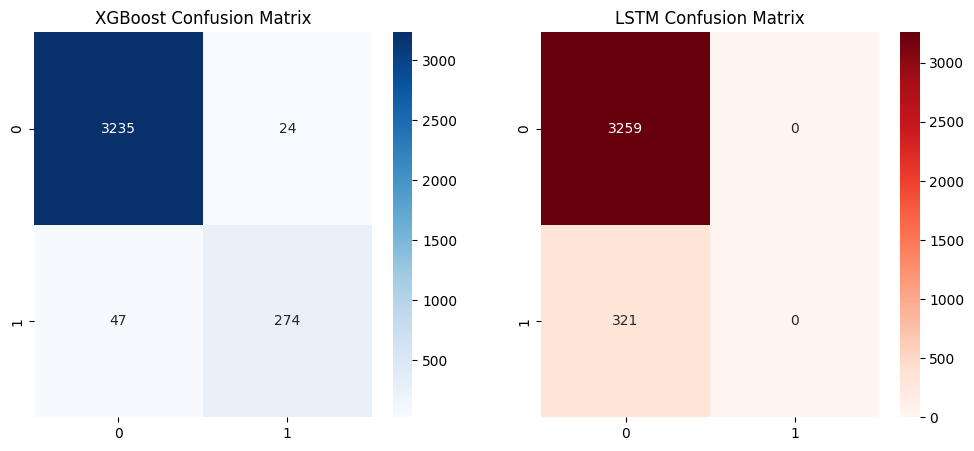

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("XGBoost Confusion Matrix")

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title("LSTM Confusion Matrix")

plt.show()


In [41]:
from sklearn.metrics import roc_auc_score

rf_proba = model_rfs.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest ROC-AUC:", rf_roc_auc)


Random Forest ROC-AUC: 0.9737123843007479


In [43]:
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)

print("XGBoost ROC-AUC:", xgb_roc_auc)


XGBoost ROC-AUC: 0.9772296033318709


In [48]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rfs),
        accuracy_score(y_test, y_pred_xgb),

    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),

    ]
})

print(results)


           Model  Accuracy   ROC-AUC
0  Random Forest  0.981285  0.973712
1        XGBoost  0.980168  0.977230
